<a href="https://colab.research.google.com/github/AtharvaChitnis/PGIT/blob/main/Marketing_Research_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective :

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [16]:
pass # Unzip command disabled as bank-full.csv is assumed to be directly available in /kaggle/input

In [17]:
df = pd.read_csv('/content/bank-full.csv', sep=';')
display(df.describe())

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [18]:
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [19]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [20]:
display(df.shape)

(45211, 17)

The target variable exhibits significant class imbalance, with the no class substantially more frequent than the yes class. Therefore, accuracy alone may not provide a reliable measure of model performance, and metrics such as precision, recall, F1-score, and ROC-AUC should also be considered.

In [22]:
display(df.isnull().sum())

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [23]:
y = df["y"]

In [24]:
X = df.drop("y", axis=1)

In [28]:
print(df['y'].value_counts(normalize=True)*100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


## Importance of Normalization for Machine Learning Models

Normalization is a crucial data preprocessing step in many machine learning workflows. Its primary goals are to transform numerical features to a common scale, preventing features with larger values from dominating those with smaller values during model training.

Here's why normalization is important:

*   **Prevents dominance by large values**

*   **Improves convergence for gradient-based optimization**

*   **Avoids bias in distance-based algorithms**

*   **Enhances interpretability**

Common normalization techniques include:
*   **Min-Max Scaling**: Scales features to a fixed range, usually 0 to 1.
*   **Standardization (Z-score normalization)**: Scales features to have a mean of 0 and a standard deviation of 1.

In [31]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
Name: count, dtype: int64

poutcome
poutcome
unknown    36959
failure     4901
ot

In [29]:
X = df.drop("y", axis=1)
y = df["y"]

In [30]:
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(45211, 16)
(45211,)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome  
0  unknown    5   may       261         1     -1         0  unknown  
1  unknown    5   may       151         1     -1         0  unknown  
2  unknown    5   may        76         1     -1         0  unknown  
3  unknown    5   may        92         1     -1         0  unknown  
4  unknown    5   may       198         1     -1         0  unknown  
0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object


In [32]:
print("Numerical columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [33]:
X = X.drop("duration", axis=1)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
no     0.883022
yes    0.116978
Name: proportion, dtype: float64
y
no     0.882999
yes    0.117001
Name: proportion, dtype: float64


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [48]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
print(y_prob)

[0.16255089 0.15700711 0.02413806 ... 0.22086476 0.21006934 0.12920544]


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8945738720141552
Precision: 0.682983682983683
Recall: 0.18462507876496534
F1: 0.2906746031746032
ROC-AUC: 0.7697034733501761

Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.99      0.94     11977
         yes       0.68      0.18      0.29      1587

    accuracy                           0.89     13564
   macro avg       0.79      0.59      0.62     13564
weighted avg       0.88      0.89      0.87     13564



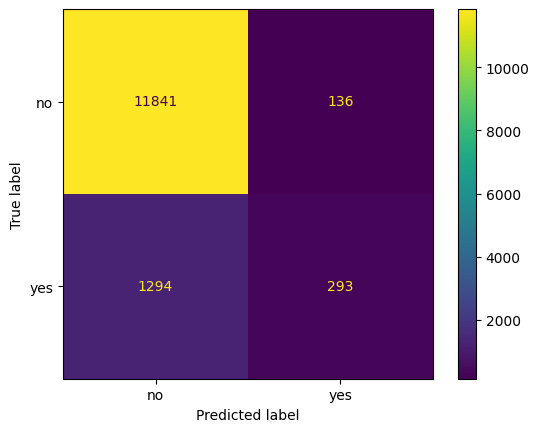

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, pos_label="yes"))
print("Recall:", recall_score(y_test, y_pred_dt, pos_label="yes"))
print("F1:", f1_score(y_test, y_pred_dt, pos_label="yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.835594219994102
Precision: 0.3080597014925373
Recall: 0.32514177693761814
F1: 0.31637032495401596
ROC-AUC: 0.6141864850288826

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.90      0.91     11977
         yes       0.31      0.33      0.32      1587

    accuracy                           0.84     13564
   macro avg       0.61      0.61      0.61     13564
weighted avg       0.84      0.84      0.84     13564



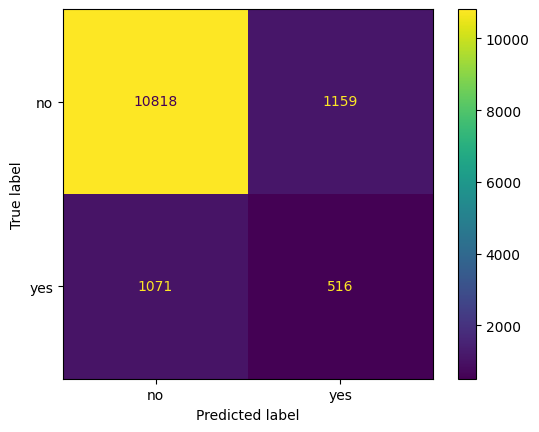

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.show()

In [54]:
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

          no       0.91      0.90      0.91     11977
         yes       0.31      0.33      0.32      1587

    accuracy                           0.84     13564
   macro avg       0.61      0.61      0.61     13564
weighted avg       0.84      0.84      0.84     13564

ROC-AUC: 0.6141864850288826


## Understanding Classification Metrics: Precision, Recall, F1-Score, and Support

When evaluating classification models, especially with imbalanced datasets (like our bank marketing dataset where 'no' is much more frequent than 'yes'), accuracy alone can be misleading. Therefore, we use a set of metrics that provide a more nuanced view of the model's performance.

Let's break down these metrics:

*   **Precision**: Also known as Positive Predictive Value, precision answers the question: "Of all the instances predicted as positive, how many were actually positive?"
    *   **Formula**: `Precision = TP / (TP + FP)`
    *   `TP` (True Positives): Correctly predicted positive instances.
    *   `FP` (False Positives): Incorrectly predicted positive instances (Type I error).
    *   **High precision** indicates a low false positive rate, meaning that when the model predicts 'yes', it is usually correct. This is important when the cost of a false positive is high.

*   **Recall**: Also known as Sensitivity or True Positive Rate, recall answers the question: "Of all the actual positive instances, how many did the model correctly identify?"
    *   **Formula**: `Recall = TP / (TP + FN)`
    *   `FN` (False Negatives): Incorrectly predicted negative instances (Type II error).
    *   **High recall** indicates a low false negative rate, meaning the model is good at finding most of the positive instances. This is important when the cost of a false negative is high.

*   **F1-Score**: The F1-Score is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall, making it particularly useful when you need to find a balance between missing positive instances and incorrectly classifying negative instances as positive.
    *   **Formula**: `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   A **high F1-Score** suggests the model has good performance on both precision and recall.

*   **Support**: Support simply refers to the number of actual occurrences of each class in the specified dataset (e.g., in `y_test`).
    *   It helps in understanding the distribution of classes and the relevance of other metrics. For instance, if a class has very low support, its precision, recall, or F1-score might be less reliable or harder to optimize.

In our context (bank marketing), 'yes' typically refers to a client subscribing to a term deposit. If the goal is to maximize subscriptions without annoying too many non-interested clients, a balance between precision and recall (or a high F1-score) might be desired. If avoiding missed opportunities (actual subscribers) is paramount, recall would be critical. If avoiding false advertising to non-subscribers is paramount, precision would be critical.